In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [14]:
parsivel_1 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
parsivel_2 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR002_Cabauw_202407.nc')

In [15]:
parsivel_1.epoch_time

<xarray.DataArray 'epoch_time' (time: 44641)>
[44641 values with dtype=int32]
Dimensions without coordinates: time
Attributes:
    long_name:  End time of observation period, in seconds since 1970-01-01 0...
    units:      s
    comment:    The length of a measurement interval is 1 minute. Values are ...

In [16]:
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values
parsivel_2['time'] = datetime_values

C:\Users\chari\AppData\Local\Temp\ipykernel_38708\1178197035.py:4: UserWarning: Converting non-nanosecond precision timedelta values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")


In [20]:
parsivel_2

<xarray.Dataset>
Dimensions:                      (time: 44641, diameter_classes: 32,
                                  velocity_classes: 32)
Coordinates:
  * time                         (time) datetime64[ns] 2024-07-01 ... 2024-08-01
Dimensions without coordinates: diameter_classes, velocity_classes
Data variables: (12/24)
    epoch_time                   (time) int32 ...
    time_as_string               (time) object ...
    lower_diameter_class_limits  (diameter_classes) float32 ...
    upper_diameter_class_limits  (diameter_classes) float32 ...
    lower_velocity_class_limits  (velocity_classes) float32 ...
    upper_velocity_class_limits  (velocity_classes) float32 ...
    ...                           ...
    sensor_temperature           (time) float64 ...
    error_code                   (time) float64 ...
    kinetic_energy               (time) float32 ...
    fieldN                       (time, diameter_classes) float32 ...
    fieldV                       (time, diameter_classes) float32 ...
    raw_data                     (time, diameter_classes, velocity_classes) float64 ...
Attributes:
    title:             OTT Parsivel2 disdrometer data
    institution:       Delft University of Technology
    source:            surface observation
    history:           produced on 2024-09-23 by Marc Schleiss
    sensor_type:       OTT Hydromet Parsivel2 optical disdrometer
    site_name:         Cabauw
    sensor_name:       PAR002_Cabauw
    logging_software:  https://github.com/ruisdael-observatory/disdroDL
    project_name:      https://ruisdael-observatory.nl/
    contributors:      Marc Schleiss, Andre Castro, Rob Mackenzie, Mahaut Sou...
    data_license:      CC BY 4.0 https://creativecommons.org/licenses/by-sa/4.0/

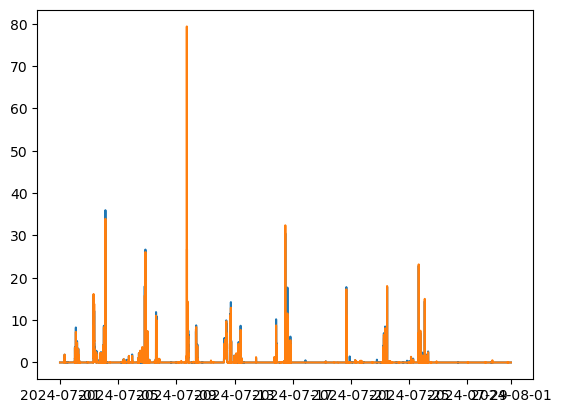

In [21]:
plt.plot(parsivel_2.time,parsivel_2.rainfall_rate_32bit)
plt.plot(parsivel_1.time,parsivel_1.rainfall_rate_32bit)

In [42]:
D = parsivel_1.rainfall_rate_32bit - parsivel_2.rainfall_rate_32bit
D_mean = D.mean()
D_var = 1/(len(D) - 1)*((D - D_mean)**2).sum()


In [ ]:
R = np.sqrt(D_var/2)
R.values

array(0.37923706)